In [1]:
import pathlib
import textwrap

import pandas as pd
from image_analysis_3D.file_utils.notebook_init_utils import init_notebook
from IPython.display import Markdown, display
from matplotlib import pyplot as plt
from pandas.plotting import table

root_dir, in_notebook = init_notebook()

In [2]:
table1_results_path = pathlib.Path(
    root_dir,
    "figures/table1_patients_and_counts/results/table1_patients_and_counts_results.tsv",
).resolve(strict=True)
table2_file_info_path = pathlib.Path(
    root_dir,
    "figures/table2/results/table2/file_info_df.parquet",
).resolve(strict=True)
table3_results_path = pathlib.Path(
    root_dir,
    "figures/table3/results/table3_patients_counts_and_image_sizes_results.tsv",
).resolve()
table3_results_path.parent.mkdir(parents=True, exist_ok=True)

In [3]:
table1_df = pd.read_csv(table1_results_path, sep="\t")
file_info_df = pd.read_parquet(table2_file_info_path)

# remove the NF0037CQ1 patient from the table
# this is a test patient and we don't want to include it in the analysis
# different microscope was used
table1_df = table1_df.loc[
    table1_df["Metadata_Biology_PatientTumor"] != "NF0037_T1_CQ1"
].reset_index(drop=True)

## Aggregate the raw image file info (table2) to the patient level

In [4]:
table2_df = (
    file_info_df.groupby("patient")
    .agg(
        TotalImages=("z_dimension_size", "sum"),
        total_size_bytes=("file_size_bytes", "sum"),
    )
    .reset_index()
)
table2_df["TotalSize(TB)"] = (table2_df["total_size_bytes"] / (1024**4)).round(2)
table2_df = table2_df.drop(columns=["total_size_bytes"])

## Combine table1 (patient/tumor level counts) and table2 (image file counts and sizes)

In [5]:
table3 = pd.merge(
    table1_df,
    table2_df,
    left_on="Metadata_Biology_PatientTumor",
    right_on="patient",
    how="left",
).drop(columns=["patient"])
table3.to_csv(table3_results_path, index=False, sep="\t")

In [6]:
tumor_type = table3.pop("Tumor_type")
table3.insert(1, "Tumor_type", tumor_type)
table3.rename(
    columns={
        "Metadata_Biology_PatientTumor": "Patient Tumor ",
        "Tumor_type": "Tumor type ",
        "number_of_compounds": "Compound Count",
        "number_of_treatments": "Treatment Count",
        "number_of_wells": "Well Count",
        "number_of_well_fovs": "Well FOV Count",
        "number_of_organoids": "Organoid Count",
        "number_of_single_cells": "Single Cell Count",
        "theoretical_number_of_compounds": "Theoretical Compound Count",
        "theoretical_number_of_treatments": "Theoretical Treatment Count",
        "theoretical_number_of_well_fovs": "Theoretical Well FOV Count",
        "TotalImages": "Total Image Count",
        "TotalSize(TB)": "Total Size (TB)",
    },
    inplace=True,
)

In [7]:
table3["Total size (TB)"] = (
    table3["Total Size (TB)"] + (table3["Total Size (TB)"] / 5) * 4
).round(2)

table3 = table3.drop(
    columns=[
        "Compound Count",
        "Well Count",
        "Theoretical Compound Count",
        "Theoretical Treatment Count",
        "Theoretical Well FOV Count",
        "Total Size (TB)",
    ]
)
# add a total row to the table
total_row = pd.DataFrame(
    {
        "Patient Tumor ": ["Total"],
        "Tumor type ": ["-"],
        "Treatment Count": [table3["Treatment Count"].sum()],
        "Well FOV Count": [table3["Well FOV Count"].sum()],
        "Organoid Count": [table3["Organoid Count"].sum()],
        "Single Cell Count": [table3["Single Cell Count"].sum()],
        "Total Image Count": [table3["Total Image Count"].sum()],
        "Total size (TB)": [table3["Total size (TB)"].sum().round(2)],
    }
)
table3 = pd.concat([table3, total_row], ignore_index=True)
table3

,Patient Tumor,Tumor type,Treatment Count,Well FOV Count,Organoid Count,Single Cell Count,Total Image Count,Total size (TB)
0,NF0014_T1,Neurofibroma (subcutaneous),21,95,191,2132,34138,0.27
1,NF0014_T2,Plexiform Neurofibroma,21,347,870,2939,85120,0.67
2,NF0016_T1,"Neurofibroma, diffuse and plexiform",20,117,257,981,27080,0.22
3,NF0018_T6,Cutaneous Neurofibroma,21,152,271,1442,38520,0.31
4,NF0021_T1,Cutaneous Neurofibroma,21,346,820,5027,84540,0.65
5,NF0030_T1,Myopericytoma,21,204,696,3755,39870,0.31
6,NF0035_T1,Cutaneous Neurofibroma,21,347,621,4780,103970,0.81
7,NF0037_T1,Cutaneous Neurofibroma,26,416,793,7489,370440,2.77
8,NF0040_T1,"Schwannoma, with degeneration",26,411,588,5006,117760,0.92
9,NF0055_T1,Plexiform Neurofibroma,25,341,731,4325,463400,3.55


In [8]:
# convert the table to a markdown table
table3_md = table3.to_markdown(index=False, tablefmt="pipe")

In [9]:
# Display the table nicely formatted

# Display as formatted markdown
print("Rendered Table:")
display(Markdown(table3_md))

Rendered Table:


| Patient Tumor    | Tumor type                                       |   Treatment Count |   Well FOV Count |   Organoid Count |   Single Cell Count |   Total Image Count |   Total size (TB) |
|:-----------------|:-------------------------------------------------|------------------:|-----------------:|-----------------:|--------------------:|--------------------:|------------------:|
| NF0014_T1        | Neurofibroma (subcutaneous)                      |                21 |               95 |              191 |                2132 |               34138 |              0.27 |
| NF0014_T2        | Plexiform Neurofibroma                           |                21 |              347 |              870 |                2939 |               85120 |              0.67 |
| NF0016_T1        | Neurofibroma, diffuse and plexiform              |                20 |              117 |              257 |                 981 |               27080 |              0.22 |
| NF0018_T6        | Cutaneous Neurofibroma                           |                21 |              152 |              271 |                1442 |               38520 |              0.31 |
| NF0021_T1        | Cutaneous Neurofibroma                           |                21 |              346 |              820 |                5027 |               84540 |              0.65 |
| NF0030_T1        | Myopericytoma                                    |                21 |              204 |              696 |                3755 |               39870 |              0.31 |
| NF0035_T1        | Cutaneous Neurofibroma                           |                21 |              347 |              621 |                4780 |              103970 |              0.81 |
| NF0037_T1        | Cutaneous Neurofibroma                           |                26 |              416 |              793 |                7489 |              370440 |              2.77 |
| NF0040_T1        | Schwannoma, with degeneration                    |                26 |              411 |              588 |                5006 |              117760 |              0.92 |
| NF0055_T1        | Plexiform Neurofibroma                           |                25 |              341 |              731 |                4325 |              463400 |              3.55 |
| SARCO219_T2      | MPNST in association with plexiform neurofibroma |                21 |              199 |             3086 |               12591 |               37150 |              0.29 |
| SARCO361_T1      | Sarcoma                                          |                21 |              349 |             1505 |                4029 |               78858 |              0.61 |
| Total            | -                                                |               265 |             3324 |            10429 |               54496 |             1480846 |             11.38 |

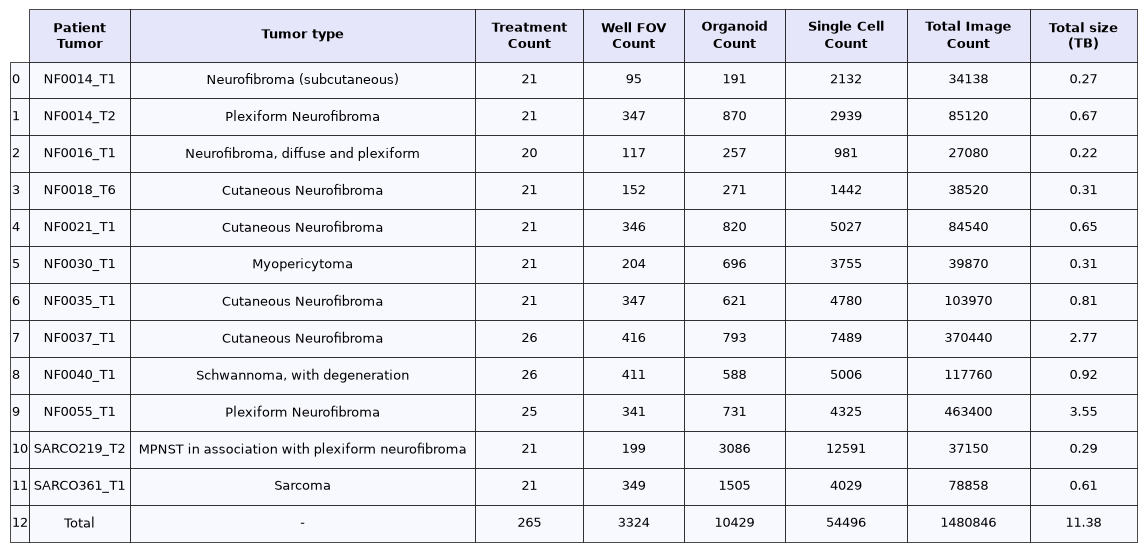

In [10]:
n_columns = table3.shape[1]


# --- Estimate a reasonable character-width budget per column ---
def col_char_width(col):
    header_len = len(str(col))
    value_len = table3[col].astype(str).map(len).max()
    return max(header_len, value_len, 6)


raw_widths = [col_char_width(c) for c in table3.columns]
total = sum(raw_widths)
col_widths = [w / total for w in raw_widths]

# --- Pre-wrap header text manually (don't rely on matplotlib's wrap=True) ---
# Wrap width in characters, scaled to how wide the column actually is.
wrapped_columns = []
for col, w in zip(table3.columns, raw_widths):
    wrap_at = max(int(w * 0.9), 8)  # characters per line, floor of 8
    wrapped = "\n".join(textwrap.wrap(str(col), width=wrap_at))
    wrapped_columns.append(wrapped)

table3_display = table3.copy()
table3_display.columns = wrapped_columns

# --- Figure sizing ---
fig_width = max(13, n_columns * 1.45)
fig, ax = plt.subplots(figsize=(fig_width, 4))
ax.axis("off")

tbl = table(
    ax,
    table3_display,
    loc="center",
    cellLoc="center",
    colWidths=col_widths,
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.1, 2.2)

# Row 0 in pandas.plotting.table is the header when index is shown.
n_header_lines = max(wc.count("\n") + 1 for wc in wrapped_columns)

for (i, j), cell in tbl.get_celld().items():
    cell.set_edgecolor("black")
    cell.set_linewidth(0.5)
    cell.set_text_props(wrap=False)  # we already hard-wrapped the text ourselves

    if i == 0:
        cell.set_facecolor("#E6E6FA")
        cell.set_text_props(weight="bold", wrap=False, linespacing=1.3)
        cell.set_height(0.06 * n_header_lines + 0.05)
    else:
        cell.set_facecolor("#F8F8FF")
        cell.set_height(0.12)

output_path = pathlib.Path(
    root_dir,
    "figures/table3/figures/table3_patients_counts_and_image_sizes.svg",
)
output_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_path, format="svg", bbox_inches="tight", dpi=600)
plt.show()